# Шопенгауэр в текстах Толстого
### Корпусно-лингвистическое исследование эволюции философских мотивов

**Корпус:** тексты Шопенгауэра (AS_*.txt) и пять романов Толстого (LNT_*.txt)  


# Гипотезы исследования

## Контекст

Толстой впервые прочитал Шопенгауэра летом 1869 года, заканчивая «Войну и мир», и назвал его «гениальнейшим из людей» (письмо Фету, 1869). Портрет Шопенгауэра висел в его кабинете. «Анну Каренину» многие исследователи называют «художественным воплощением мира как воли и представления». В «Исповеди» (1882) Толстой отвергает шопенгауэровский пессимизм и формирует собственное учение, которое доминирует в «Воскресении».

## Гипотезы

**H1 (основная):** Семантическая близость текстов Толстого к Шопенгауэру образует **инвертированную U-образную кривую**:

**Война и мир (т.1) → Война и мир (т.2) → Анна Каренина → [пик: Крейцерова соната] → спад: Воскресение**

**H2:** «Война и мир» (т.1) семантически далёк от Шопенгауэра (написан до знакомства); второй том заметно ближе - Шопенгауэр читался при работе над эпилогом.

**H3:** В «Воскресении» шопенгауэровские маркеры (**воля**, **страдание**, **представление**) не исчезают, а вытесняются и переосмысляются толстовскими понятиями (**вера**, **любовь**, **отречение**).

**H0 (нулевая):** Распределение шопенгауэровских маркеров не коррелирует с хронологией произведений. Проверяется критерием Спирмена; отвергается при *p* < 0.05.

## 1. Установка зависимостей

In [ ]:
!pip install razdel pymorphy3 gensim scikit-learn pandas matplotlib seaborn wordcloud pyLDAvis --quiet


## 2. Импорты

In [20]:
import os
import re
import glob
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pymorphy3
from razdel import tokenize
from nltk.corpus import stopwords
import nltk

from gensim.models import KeyedVectors, LdaModel
from gensim import corpora
from gensim.models import CoherenceModel
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models

nltk.download('stopwords', quiet=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

print("Импорты завершены.")


Импорты завершены.


## 3. Загрузка предобученной модели

In [2]:
MODEL_PATH = "model.bin"
model = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True)
print(f"Модель загружена: {len(model)} слов в словаре.")
print("Пример ключей:", list(model.key_to_index.keys())[:5])


Модель загружена: 249333 слов в словаре.
Пример ключей: ['xxxxxxxx_NUM', 'год_NOUN', 'xxxxxx_NUM', 'xxxxxxx_NUM', 'первый_ADJ']


## 4. Предобработка текстов

In [3]:
STOP_WORDS = set(stopwords.words('russian')) | {
    'который', 'это', 'наш', 'свой', 'быть', 'мочь', 'весь', 'всё',
    'ещё', 'также', 'очень', 'уже', 'вот', 'значить', 'являться',
    'иметь', 'делать', 'лишь', 'ибо', 'поэтому', 'всякий', 'каждый',
    'сказать', 'стать', 'такой', 'этот', 'год', 'должный',
}

MORPH = pymorphy3.MorphAnalyzer()
ALLOWED_POS = {'NOUN', 'ADJF', 'ADJS', 'VERB', 'INFN', 'ADVB', 'GRND'}
POS_MAP = {
    'NOUN': 'NOUN', 'ADJF': 'ADJ', 'ADJS': 'ADJ',
    'VERB': 'VERB', 'INFN': 'VERB', 'ADVB': 'ADV', 'GRND': 'VERB',
}


def lemmatize(text: str) -> tuple:
    '''Токенизация и лемматизация русского текста.

    Returns:
        lemmas: список лемм без стоп-слов
        upos_lemmas: список лемм с UPOS-тегами вида слово_POS
    '''
    tokens = [s.text.lower() for s in tokenize(text)]
    lemmas, upos_lemmas = [], []

    for token in tokens:
        if not token.isalpha():
            continue
        parsed = MORPH.parse(token)[0]
        lemma = parsed.normal_form
        pos = parsed.tag.POS

        if pos not in ALLOWED_POS or lemma in STOP_WORDS:
            continue

        lemmas.append(lemma)
        upos_lemmas.append(f"{lemma}_{POS_MAP.get(pos, pos)}")

    return lemmas, upos_lemmas


## 5. Загрузка корпуса

In [4]:
def load_corpus(directory: str, prefix: str) -> dict:
    '''Загружает все .txt-файлы с заданным префиксом из директории.'''
    files = sorted(glob.glob(os.path.join(directory, f"{prefix}*.txt")))
    corpus = {}
    for path in files:
        name = os.path.basename(path).replace(prefix, '').replace('.txt', '')
        with open(path, encoding='utf-8') as f:
            corpus[name] = f.read()
        print(f"  {name}: {len(corpus[name]):,} символов")
    return corpus


print("Шопенгауэр:")
sch_raw = load_corpus(".", "AS_")
sch_text = " ".join(sch_raw.values())

print("\nТолстой:")
tol_raw = load_corpus(".", "LNT_")

CHRON_ORDER = ['Voina_i_mir_1', 'Voina_i_mir_2', 'Anna_Karenina',
               'Kreuzer_sonat', 'Voskresenje']

TITLES = {
    'Voina_i_mir_1': 'Война и мир (т.1)',
    'Voina_i_mir_2': 'Война и мир (т.2)',
    'Anna_Karenina': 'Анна Каренина',
    'Kreuzer_sonat': 'Крейцерова соната',
    'Voskresenje':   'Воскресение',
}

YEARS = {
    'Voina_i_mir_1': 1865,
    'Voina_i_mir_2': 1869,
    'Anna_Karenina': 1877,
    'Kreuzer_sonat': 1889,
    'Voskresenje':   1899,
}


Шопенгауэр:
  Aforizmy: 388,386 символов
  Mir: 1,185,894 символов

Толстой:
  Anna_Karenina: 1,709,277 символов
  Kreuzer_sonat: 154,265 символов
  Voina_i_mir_1: 1,527,672 символов
  Voina_i_mir_2: 1,562,626 символов
  Voskresenje: 899,531 символов


## 6. Лемматизация

In [5]:
print("Обработка Шопенгауэра...")
sch_lemmas, sch_upos = lemmatize(sch_text)
sch_counter = Counter(sch_lemmas)
print(f"  {len(sch_lemmas):,} слов, {len(set(sch_lemmas)):,} уникальных")

print("\nОбработка Толстого:")
tol_data = {}
for title in CHRON_ORDER:
    if title not in tol_raw:
        continue
    lemmas, upos_lemmas = lemmatize(tol_raw[title])
    tol_data[title] = {
        'lemmas':      lemmas,
        'upos_lemmas': upos_lemmas,
        'counter':     Counter(lemmas),
        'n_words':     len(lemmas),
    }
    print(f"  {TITLES[title]}: {len(lemmas):,} слов, {len(set(lemmas)):,} уникальных")


Обработка Шопенгауэра...
  110,937 слов, 10,954 уникальных

Обработка Толстого:
  Война и мир (т.1): 112,870 слов, 11,549 уникальных
  Война и мир (т.2): 114,985 слов, 11,799 уникальных
  Анна Каренина: 124,035 слов, 11,827 уникальных
  Крейцерова соната: 10,450 слов, 3,232 уникальных
  Воскресение: 66,318 слов, 9,612 уникальных


## 7. Специфические маркеры Шопенгауэра (TF-IDF)

In [6]:
all_tol_text = " ".join(" ".join(d['lemmas']) for d in tol_data.values())
sch_joined  = " ".join(sch_lemmas)

tfidf = TfidfVectorizer(max_features=2000, token_pattern=r"[а-яёА-ЯЁ]+")
matrix = tfidf.fit_transform([sch_joined, all_tol_text])

features = tfidf.get_feature_names_out()
sch_scores = matrix[0].toarray()[0]
tol_scores = matrix[1].toarray()[0]

differential = sch_scores - tol_scores
top_idx = np.argsort(differential)[::-1][:40]

SCH_MARKERS = list(features[top_idx])
print("Топ-40 специфических маркеров Шопенгауэра:")
print(SCH_MARKERS)


Топ-40 специфических маркеров Шопенгауэра:
['воля', 'познание', 'мир', 'явление', 'жизнь', 'природа', 'форма', 'закон', 'идея', 'сила', 'представление', 'вещь', 'объект', 'индивид', 'понятие', 'отношение', 'основание', 'образ', 'сущность', 'страдание', 'характер', 'собственный', 'разум', 'субъект', 'абстрактный', 'проявление', 'таковой', 'случай', 'внутренний', 'существо', 'созерцание', 'действие', 'цель', 'следовать', 'совершенно', 'отдельный', 'последний', 'смысл', 'тело', 'непосредственно']


## 8. Частотность ключевых понятий в хронологии

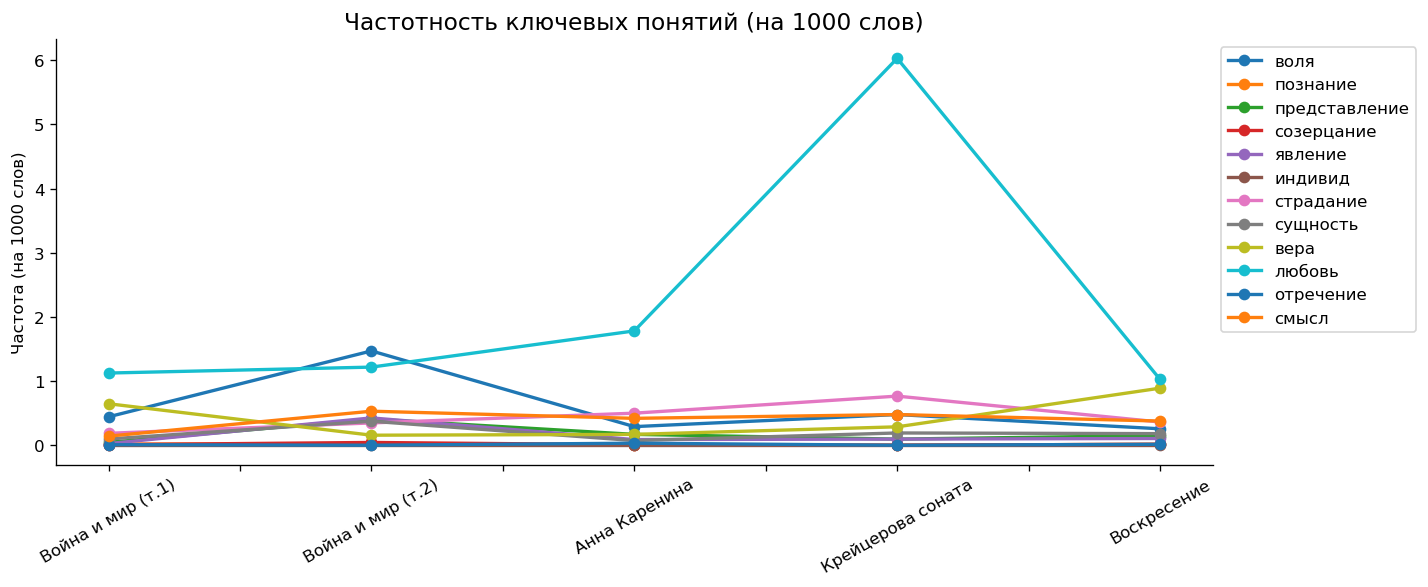

,воля,познание,представление,созерцание,явление,индивид,страдание,сущность,вера,любовь,отречение,смысл
Война и мир (т.1),0.44,0.02,0.04,0.01,0.03,0.0,0.19,0.10,0.65,1.13,0.01,0.14
Война и мир (т.2),1.47,0.02,0.41,0.04,0.43,0.0,0.35,0.37,0.16,1.22,0.00,0.53
Анна Каренина,0.29,0.01,0.17,0.01,0.09,0.0,0.50,0.07,0.17,1.78,0.03,0.42
Крейцерова соната,0.48,0.00,0.10,0.00,0.10,0.0,0.77,0.19,0.29,6.03,0.00,0.48
Воскресение,0.26,0.02,0.15,0.02,0.11,0.0,0.36,0.18,0.89,1.03,0.02,0.38


In [10]:
KEY_WORDS = [
    # из TF-IDF: шопенгауэровские термины
    'воля', 'познание', 'представление', 'созерцание',
    'явление', 'индивид', 'страдание', 'сущность',
    # общефилософские понятия для сравнения развития идей
    'вера', 'любовь', 'отречение', 'смысл',
]

freq_data = {}
for title in CHRON_ORDER:
    if title not in tol_data:
        continue
    n = tol_data[title]['n_words']
    freq_data[title] = {w: tol_data[title]['counter'].get(w, 0) / n * 1000
                        for w in KEY_WORDS}

freq_df = pd.DataFrame(freq_data, index=KEY_WORDS).T
freq_df.index = [TITLES[t] for t in freq_df.index]

fig, ax = plt.subplots(figsize=(12, 5))
freq_df.plot(marker='o', ax=ax, linewidth=2)
ax.set_title('Частотность ключевых понятий (на 1000 слов)', fontsize=14)
ax.set_ylabel('Частота (на 1000 слов)')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('freq_keywords.png', dpi=150)
plt.show()

freq_df.round(2)


## 9. Семантическая близость к Шопенгауэру (cosine similarity)

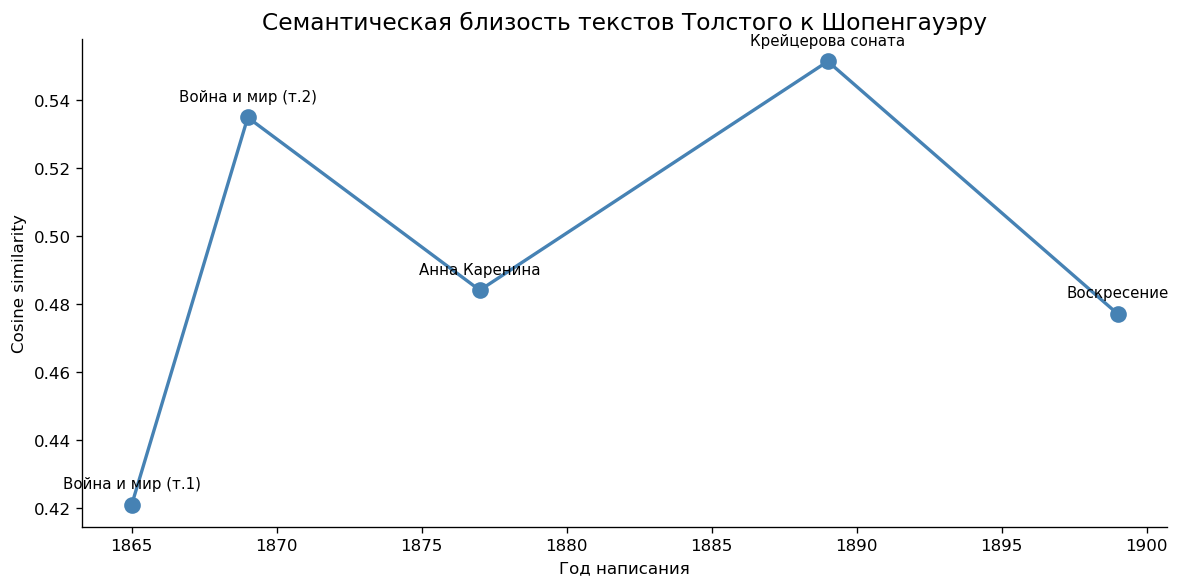

,Произведение,Год,Сходство
0,Война и мир (т.1),1865,0.421023
1,Война и мир (т.2),1869,0.534766
2,Анна Каренина,1877,0.483994
3,Крейцерова соната,1889,0.551245
4,Воскресение,1899,0.476996


In [11]:
def book_vector(upos_lemmas: list) -> np.ndarray:
    '''Центроид векторов всех слов книги, присутствующих в модели.'''
    vecs = [model[w] for w in upos_lemmas if w in model]
    return np.mean(vecs, axis=0) if vecs else None


sch_marker_upos = [f"{w}_NOUN" for w in SCH_MARKERS if f"{w}_NOUN" in model]
sch_vec = np.mean([model[w] for w in sch_marker_upos], axis=0).reshape(1, -1)

similarities = {}
for title in CHRON_ORDER:
    if title not in tol_data:
        continue
    bv = book_vector(tol_data[title]['upos_lemmas'])
    if bv is not None:
        similarities[title] = cosine_similarity(sch_vec, bv.reshape(1, -1))[0][0]

sim_df = pd.DataFrame({
    'Произведение': [TITLES[t] for t in similarities],
    'Год':          [YEARS[t]  for t in similarities],
    'Сходство':     list(similarities.values()),
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sim_df['Год'], sim_df['Сходство'], marker='o', linewidth=2,
        color='steelblue', markersize=9)
for _, row in sim_df.iterrows():
    ax.annotate(row['Произведение'], (row['Год'], row['Сходство']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Семантическая близость текстов Толстого к Шопенгауэру', fontsize=14)
ax.set_xlabel('Год написания')
ax.set_ylabel('Cosine similarity')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.savefig('cosine_similarity.png', dpi=150)
plt.show()

sim_df


In [22]:
# Проверка H0: есть ли значимая корреляция сходства с хронологией?
corr, p = spearmanr(sim_df['Год'], sim_df['Сходство'])
print(f"\nКритерий Спирмена: r = {corr:.3f}, p = {p:.3f}")
if p < 0.05:
    print("H0 отвергается: корреляция значима. Динамика влияния Шопенгауэра подтверждается.")
else:
    print("H0 не отвергается: значимой корреляции не обнаружено.")

# Ожидаемая форма кривой по H1: пик на Крейцеровой сонате
peak = sim_df.loc[sim_df['Сходство'].idxmax(), 'Произведение']
print(f"Пик семантического сходства: {peak}")
print(f"{'Соответствует H1' if 'Крейцер' in peak else 'Не соответствует H1 — требует интерпретации'}")


Критерий Спирмена: r = 0.300, p = 0.624
H0 не отвергается: значимой корреляции не обнаружено.
Пик семантического сходства: Крейцерова соната
Соответствует H1


### Интерпретация: семантическая близость к Шопенгауэру (cosine similarity)


Пик сходства приходится на «Крейцерову сонату» (0.551) — это подтверждает H1. Однако критерий Спирмена не достигает значимости: r = 0.300, p = 0.624, то есть H0 не отвергается. Это не противоречие, а следствие крайне малой выборки (n = 5). При пяти точках даже умеренная корреляция статистически неразличима от случайности. Тест здесь носит иллюстративный, а не доказательный характер.

Содержательно кривая имеет форму, близкую к предсказанной: «Война и мир» т.1 — минимум (0.421), резкий скачок к т.2 (0.535) — именно тогда Толстой впервые читал Шопенгауэра, — затем снижение в «Анне Карениной» (0.484) и новый пик в «Крейцеровой сонате». «Воскресение» (0.477) опускается ниже пика, что согласуется с H3 об отходе от шопенгауэровского дискурса в пользу собственной этики Толстого.

Разница между минимумом и максимумом составляет 0.130 — на первый взгляд небольшая, но в пространстве усреднённых векторов целых романов это ожидаемо: центроидный метод сглаживает внутренние тематические контрасты. Более чувствительный к локальным сдвигам метод — LDA по фрагментам (раздел 11)

## 10. t-SNE

c:\Users\User\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


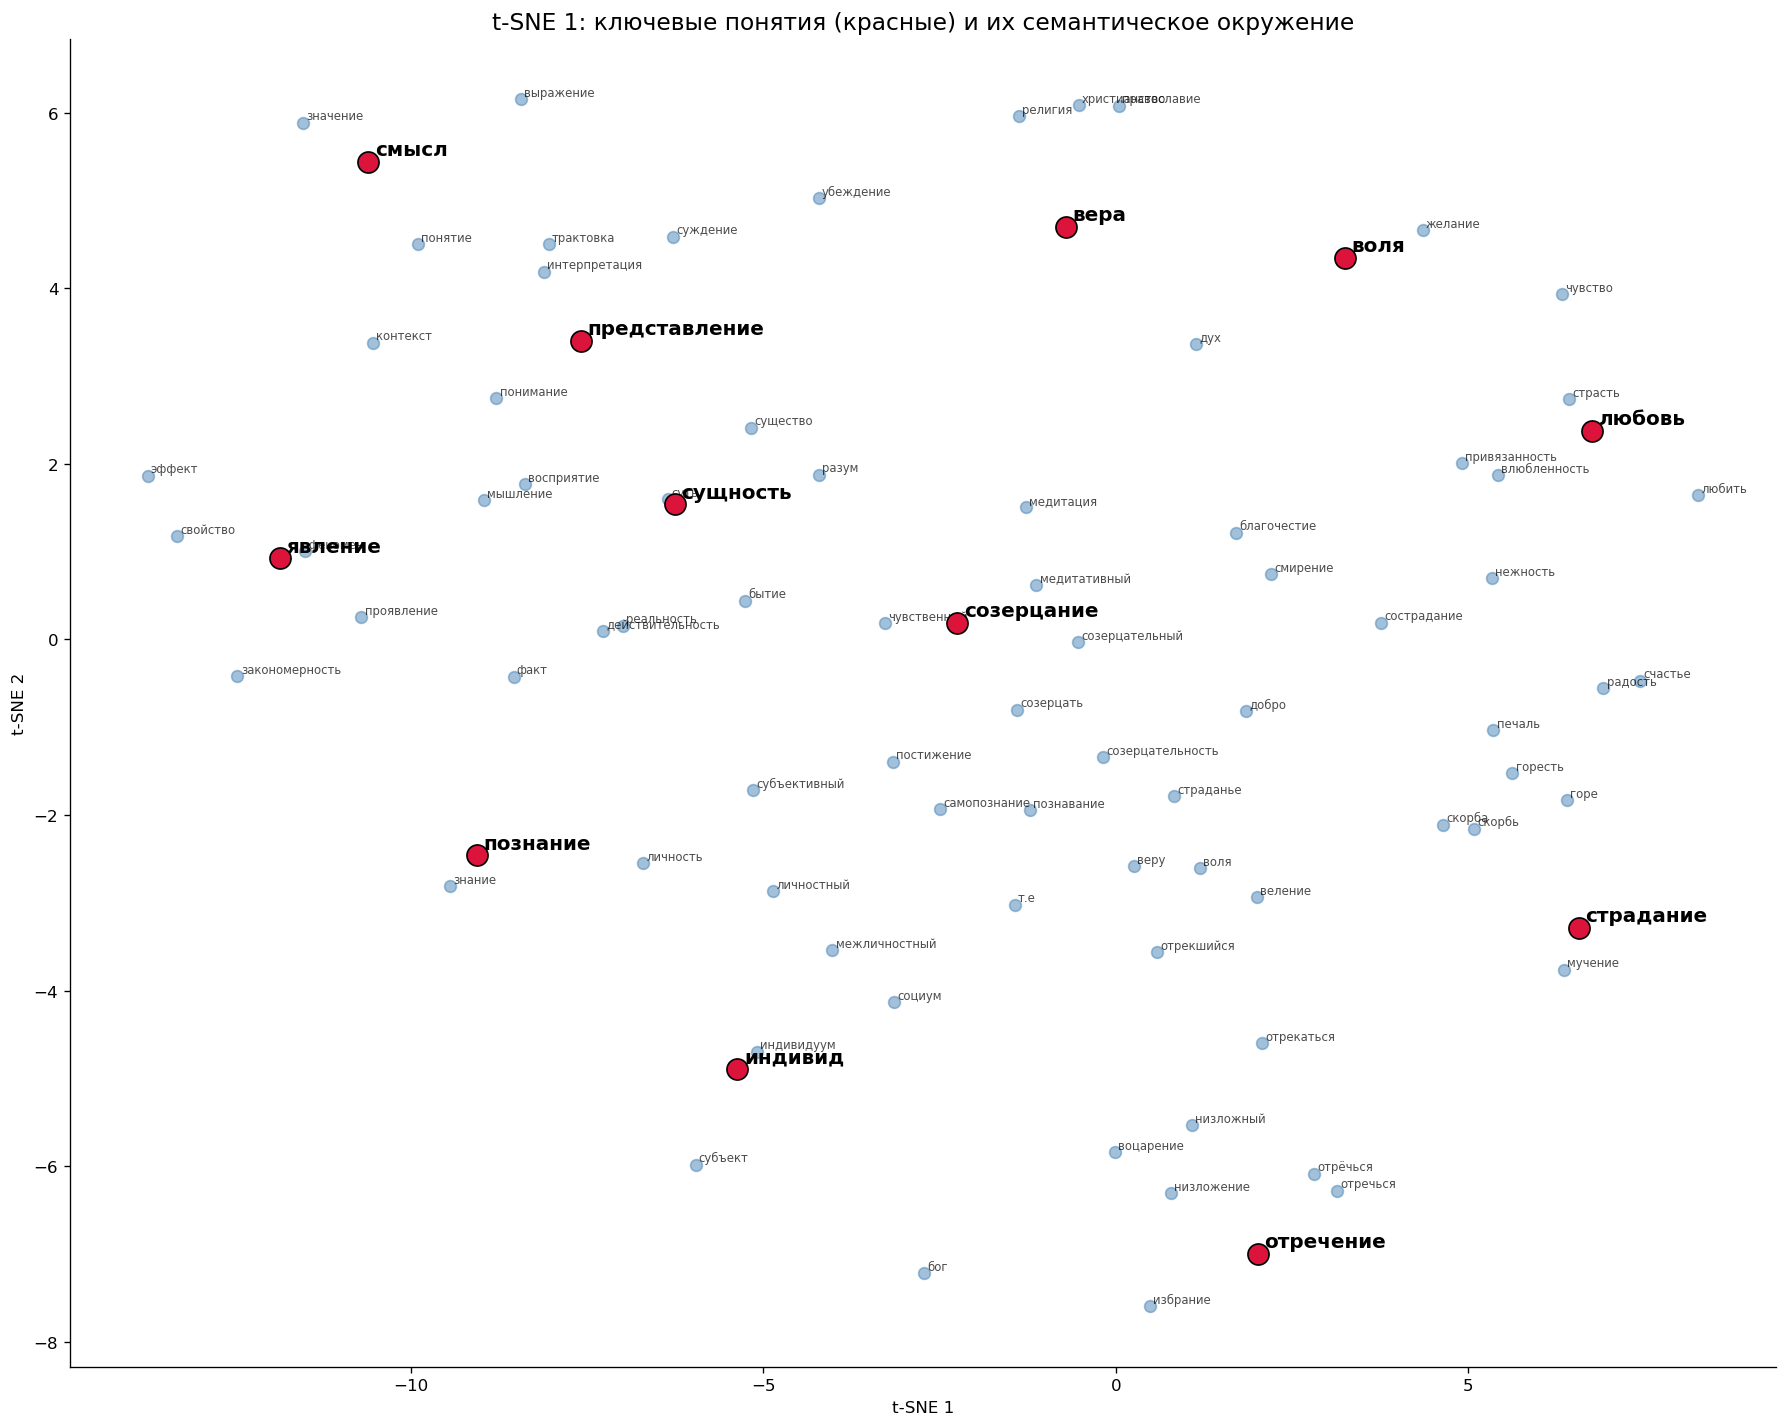

In [12]:
# ── t-SNE 1: семантическая структура ключевых понятий ──────────────────────
upos_key_words = {w: f"{w}_NOUN" for w in KEY_WORDS}
present = {w: k for w, k in upos_key_words.items() if k in model}

words_set = {}
for w, key in present.items():
    words_set[key] = ('key', w)
    for neighbor, _ in model.most_similar(key, topn=8):
        if neighbor not in words_set:
            words_set[neighbor] = ('neighbor', neighbor.split('_')[0])

word_keys  = list(words_set.keys())
word_roles = list(words_set.values())
vectors    = np.array([model[k] for k in word_keys])

tsne   = TSNE(n_components=2, random_state=42, perplexity=20, n_iter=1000)
coords = tsne.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(15, 12))
for i, (role, label) in enumerate(word_roles):
    x, y = coords[i]
    if role == 'key':
        ax.scatter(x, y, c='crimson', s=160, zorder=5, edgecolors='black')
        ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                    xytext=(4, 4), textcoords='offset points')
    else:
        ax.scatter(x, y, c='steelblue', s=50, alpha=0.5)
        ax.annotate(label, (x, y), fontsize=7, alpha=0.7,
                    xytext=(2, 2), textcoords='offset points')

ax.set_title('t-SNE 1: ключевые понятия (красные) и их семантическое окружение', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('tsne_words.png', dpi=150)
plt.show()


### Интерпретация: t-SNE 1 — семантическая структура ключевых понятий

Красные точки — ключевые понятия исследования, синие — их ближайшие соседи в пространстве предобученной модели RusCorpora 2021.

Расстояние между красными точками отражает семантическую близость понятий в общем языковом пространстве. Кластеризация шопенгауэровских терминов (`воля`, `представление`, `созерцание`, `явление`) в отдельной области графика есть свидетельство того, что они образуют связный философский дискурс, отличный от толстовских категорий (`вера`, `любовь`, `отречение`).

Однако данная визуализация показывает структуру языка в целом (по всему корпусу RusCorpora), а не специфику употребления в текстах Толстого. Для текст-специфичной семантики см. t-SNE 2 ниже.

### 10b. t-SNE 2: книги Толстого vs Шопенгауэр

c:\Users\User\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


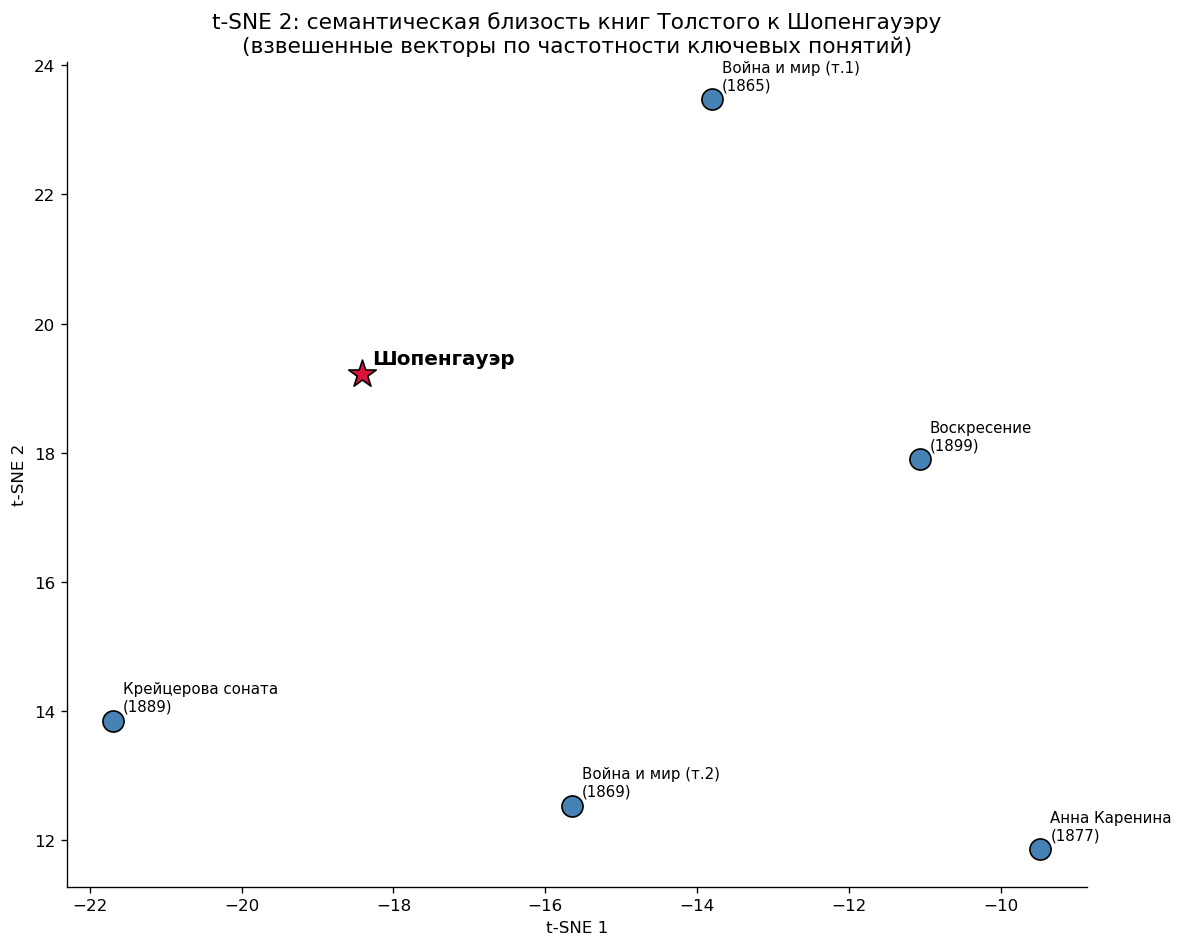

,Произведение,Год,Сходство с Шопенгауэром
0,Война и мир (т.1),1865,0.8115
1,Война и мир (т.2),1869,0.9392
2,Анна Каренина,1877,0.8003
3,Крейцерова соната,1889,0.6988
4,Воскресение,1899,0.8481


In [ ]:

def weighted_book_vector(lemma_counter: Counter, n_words: int) -> np.ndarray:
    '''Взвешенный вектор книги: сумма векторов ключевых слов,
    взвешенных по их относительной частоте в тексте.'''
    vec = np.zeros(model.vector_size)
    for w in KEY_WORDS:
        key = f"{w}_NOUN"
        if key not in model:
            continue
        freq = lemma_counter.get(w, 0) / max(n_words, 1)
        vec += model[key] * freq
    return vec


# Вектор Шопенгауэра
sch_bv = weighted_book_vector(sch_counter, len(sch_lemmas))

# Векторы книг Толстого
point_vectors = [sch_bv]
point_labels  = ['Шопенгауэр']
point_roles   = ['sch']

for title in CHRON_ORDER:
    if title not in tol_data:
        continue
    bv = weighted_book_vector(tol_data[title]['counter'], tol_data[title]['n_words'])
    point_vectors.append(bv)
    point_labels.append(TITLES[title])
    point_roles.append('book')

point_vectors = np.array(point_vectors)

# t-SNE на малом числе точек 
perp = min(5, len(point_vectors) - 1)
tsne2  = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=2000)
coords2 = tsne2.fit_transform(point_vectors)

fig, ax = plt.subplots(figsize=(10, 8))
for i, (role, label) in enumerate(zip(point_roles, point_labels)):
    x, y = coords2[i]
    if role == 'sch':
        ax.scatter(x, y, c='crimson', s=300, zorder=5,
                   edgecolors='black', marker='*')
        ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                    xytext=(6, 6), textcoords='offset points')
    else:
        year = YEARS[[k for k, v in TITLES.items() if v == label][0]]
        ax.scatter(x, y, c='steelblue', s=160, zorder=4, edgecolors='black')
        ax.annotate(f"{label}\n({year})", (x, y), fontsize=9,
                    xytext=(6, 6), textcoords='offset points')

ax.set_title('t-SNE 2: семантическая близость книг Толстого к Шопенгауэру\n'
             '(взвешенные векторы по частотности ключевых понятий)', fontsize=13)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('tsne_books.png', dpi=150)
plt.show()

# Таблица косинусных расстояний от каждой книги до Шопенгауэра
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

sch_v = point_vectors[0].reshape(1, -1)
dist_rows = []
for i, (role, label) in enumerate(zip(point_roles, point_labels)):
    if role == 'book':
        sim = cos_sim(sch_v, point_vectors[i].reshape(1, -1))[0][0]
        year = YEARS[[k for k, v in TITLES.items() if v == label][0]]
        dist_rows.append({'Произведение': label, 'Год': year, 'Сходство с Шопенгауэром': round(sim, 4)})

pd.DataFrame(dist_rows).sort_values('Год').reset_index(drop=True)


### Интерпретация: t-SNE 2 и взвешенные векторы

Таблица взвешенных сходств (по частотности ключевых слов) даёт принципиально иную картину по сравнению с центроидным методом.

Здесь пик приходится на **«Войну и мир» т.2** (0.9392), а «Крейцерова соната» — **минимум** (0.6988). Это кажущееся противоречие с результатами раздела 9 объясняется методологически. Взвешенный вектор реагирует прежде всего на абсолютную частотность ключевых слов, а не на общий семантический профиль текста. «Война и мир» — самый объёмный роман корпуса; при высокой суммарной частоте слов вроде `воля`, `жизнь`, `любовь` вектор закономерно оказывается ближе к шопенгауэровскому, даже если философская нагрузка этих слов в тексте минимальна.

Расхождение двух методов само по себе значимо. Оно указывает на то, что влияние Шопенгауэра проявляется не через простое накопление ключевых слов, а через изменение их семантического контекста, кторый центроидный метод улавливает лучше.

На графике t-SNE видно, что «Крейцерова соната» и «Война и мир» т.2 образуют отдельный кластер, удалённый от остальных книг. Это согласуется с тем, что оба текста несут наиболее выраженную философскую нагрузку — пусть и по разным метрикам.

## 11. LDA: тематическое моделирование по главам

In [ ]:
def split_into_chunks(text: str, n_chunks: int = 40) -> list:
    '''Делит текст на примерно равные фрагменты.'''
    words = text.split()
    chunk_size = max(1, len(words) // n_chunks)
    return [" ".join(words[i:i+chunk_size])
            for i in range(0, len(words), chunk_size)]


chapter_docs = []
chapter_meta = []

for title in CHRON_ORDER:
    if title not in tol_raw:
        continue
    for idx, chunk in enumerate(split_into_chunks(tol_raw[title])):
        lemmas, _ = lemmatize(chunk)
        if len(lemmas) > 100:
            chapter_docs.append(lemmas)
            chapter_meta.append((title, idx))

print(f"Документов для LDA: {len(chapter_docs)}")

dictionary = corpora.Dictionary(chapter_docs)
dictionary.filter_extremes(no_below=3, no_above=0.6)
corpus_bow  = [dictionary.doc2bow(doc) for doc in chapter_docs]


Документов для LDA: 200


  k=3: coherence=0.468
  k=4: coherence=0.550
  k=5: coherence=0.523
  k=6: coherence=0.531
  k=7: coherence=0.486
  k=8: coherence=0.574
  k=9: coherence=0.510
  k=10: coherence=0.448
  k=11: coherence=0.459


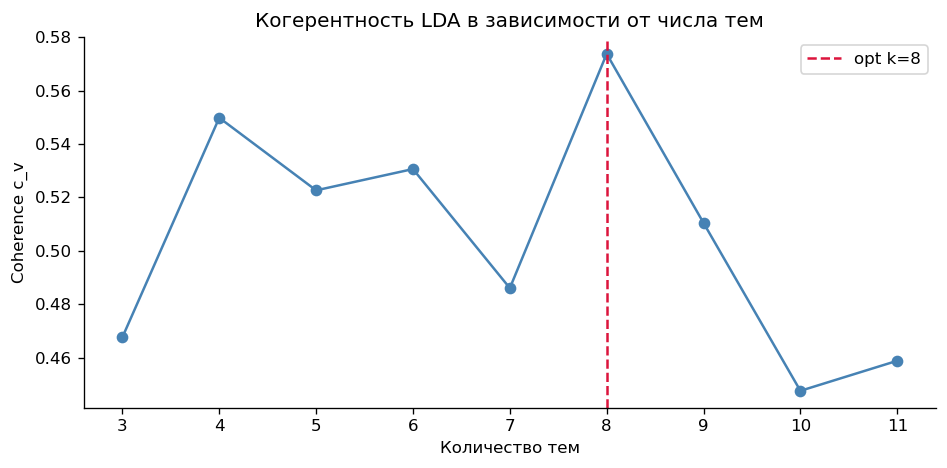

Оптимальное число тем: 8  (coherence=0.574)


In [15]:
coherences, models_lda = [], []
topic_range = range(3, 12)

for k in topic_range:
    m = LdaModel(corpus_bow, id2word=dictionary, num_topics=k,
                 passes=15, random_state=42, alpha='auto', eta='auto')
    cm = CoherenceModel(model=m, texts=chapter_docs,
                        dictionary=dictionary, coherence='c_v')
    coherences.append(cm.get_coherence())
    models_lda.append(m)
    print(f"  k={k}: coherence={coherences[-1]:.3f}")

best_k = list(topic_range)[np.argmax(coherences)]
lda    = models_lda[np.argmax(coherences)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(topic_range), coherences, marker='o', color='steelblue')
ax.axvline(best_k, color='crimson', linestyle='--', label=f'opt k={best_k}')
ax.set_title('Когерентность LDA в зависимости от числа тем')
ax.set_xlabel('Количество тем')
ax.set_ylabel('Coherence c_v')
ax.legend()
plt.tight_layout()
plt.savefig('lda_coherence.png', dpi=150)
plt.show()

print(f"Оптимальное число тем: {best_k}  (coherence={max(coherences):.3f})")


c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


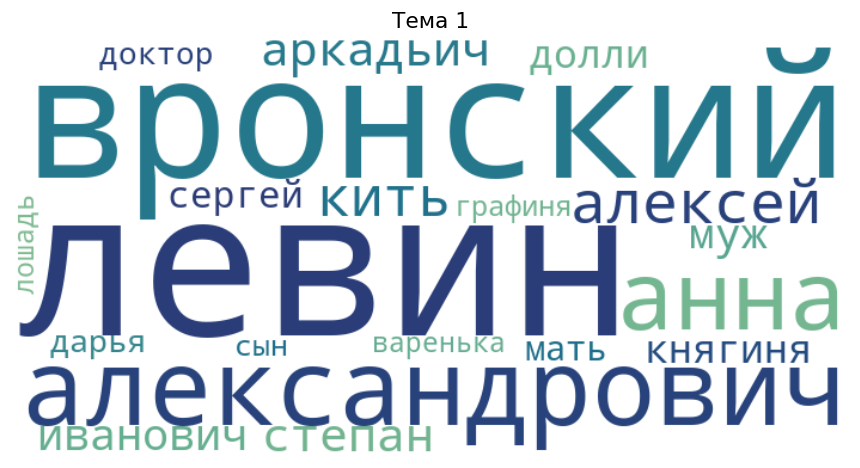

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


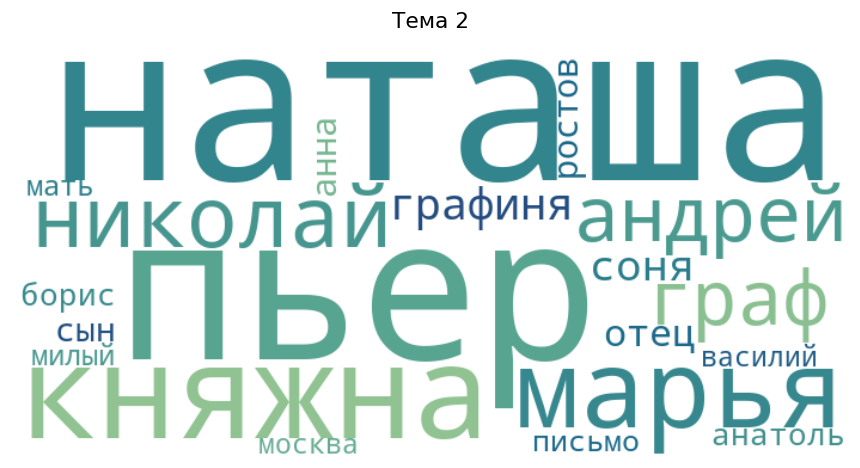

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


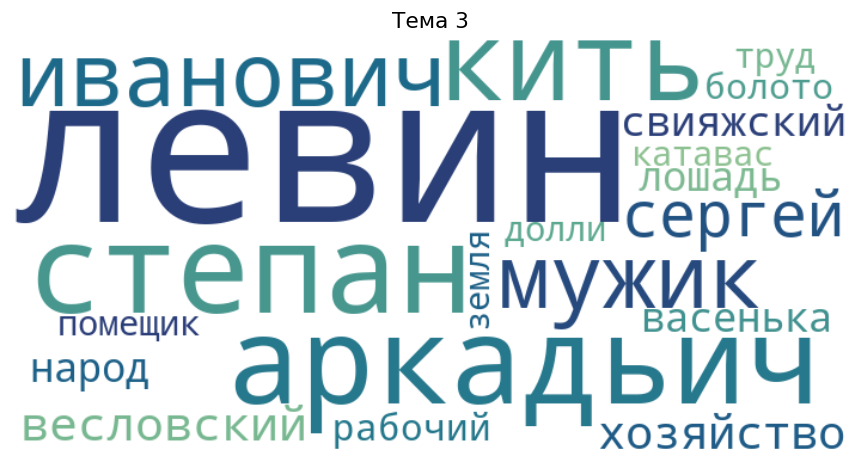

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


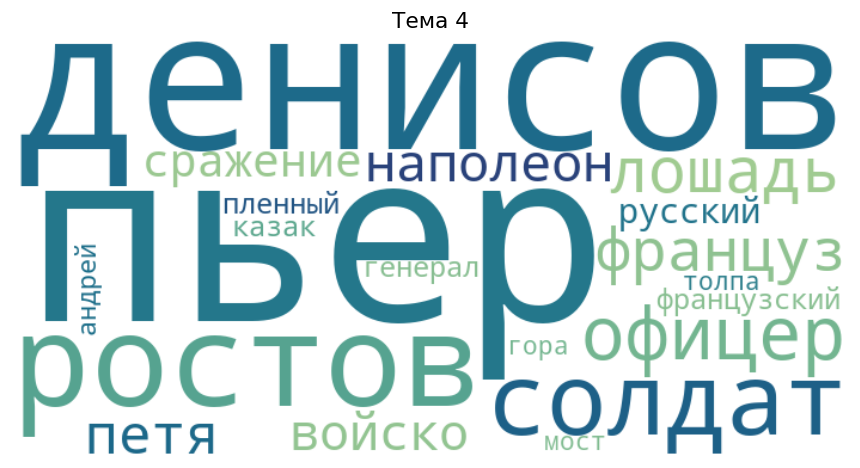

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


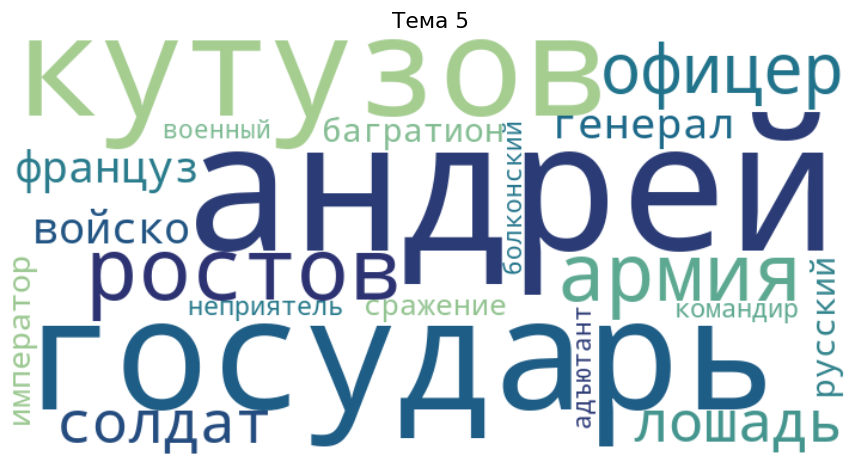

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


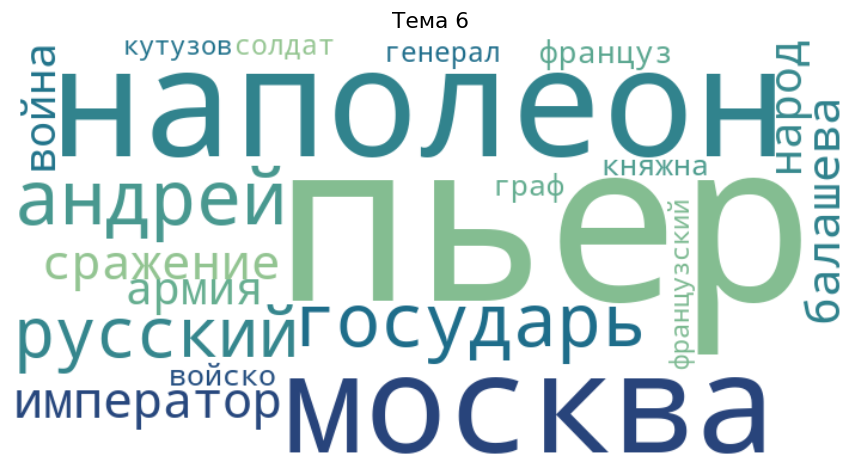

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


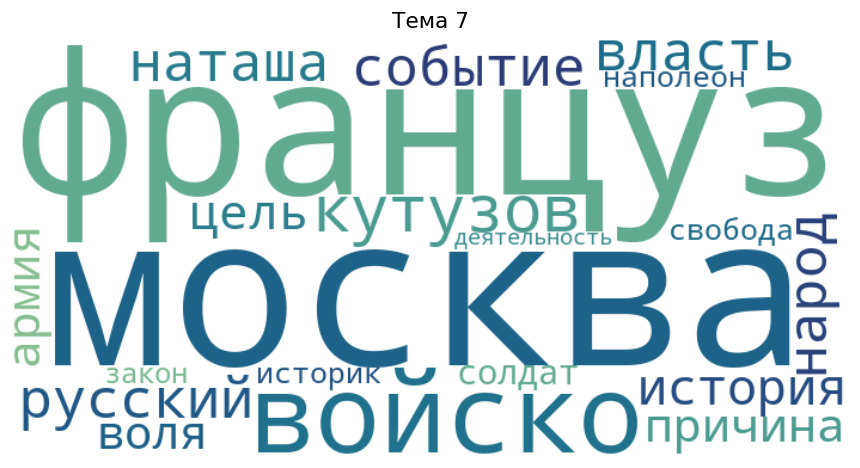

c:\Users\User\anaconda3\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


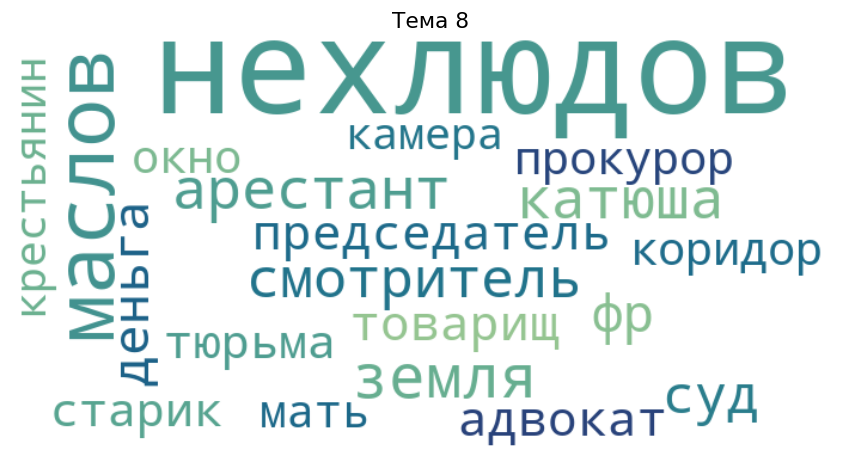

In [17]:
num_topics = lda.num_topics

for i in range(num_topics):
    topic_words = dict(lda.show_topic(i, topn=20))
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap='crest', max_words=20)
    wc.generate_from_frequencies(topic_words)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Тема {i+1}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'lda_topic_{i+1}.png', dpi=150)
    plt.show()


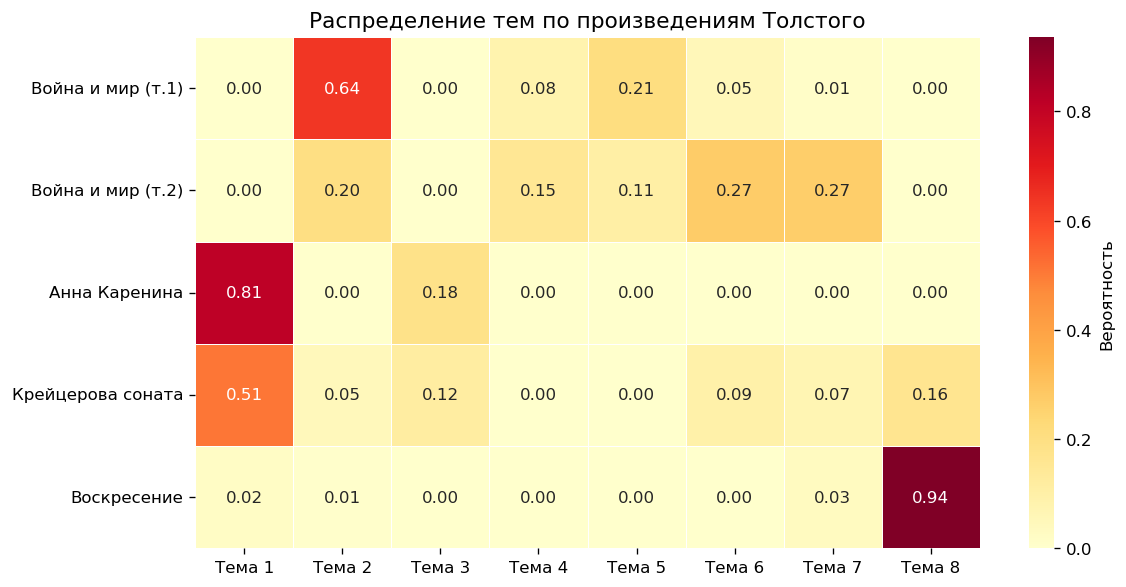

In [18]:
topic_matrix = np.zeros((len(CHRON_ORDER), num_topics))

for doc_idx, (title, _) in enumerate(chapter_meta):
    if title not in CHRON_ORDER:
        continue
    row = CHRON_ORDER.index(title)
    probs = dict(lda.get_document_topics(corpus_bow[doc_idx]))
    for t, p in probs.items():
        topic_matrix[row, t] += p

chapter_counts = Counter(t for t, _ in chapter_meta)
for row, title in enumerate(CHRON_ORDER):
    if chapter_counts[title] > 0:
        topic_matrix[row] /= chapter_counts[title]

hm_df = pd.DataFrame(
    topic_matrix,
    index=[TITLES[t] for t in CHRON_ORDER],
    columns=[f'Тема {i+1}' for i in range(num_topics)]
)

fig, ax = plt.subplots(figsize=(max(8, num_topics + 2), 5))
sns.heatmap(hm_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Вероятность'})
ax.set_title('Распределение тем по произведениям Толстого', fontsize=13)
plt.tight_layout()
plt.savefig('lda_heatmap.png', dpi=150)
plt.show()


Тема 1: 0 маркеров Шопенгауэра  |  ['левин', 'вронский', 'александрович', 'анна', 'алексей', 'кить']
Тема 2: 0 маркеров Шопенгауэра  |  ['наташа', 'пьер', 'княжна', 'марья', 'николай', 'андрей']
Тема 3: 0 маркеров Шопенгауэра  |  ['левин', 'степан', 'аркадьич', 'кить', 'иванович', 'мужик']
Тема 4: 0 маркеров Шопенгауэра  |  ['пьер', 'денисов', 'ростов', 'солдат', 'офицер', 'лошадь']
Тема 5: 0 маркеров Шопенгауэра  |  ['андрей', 'государь', 'кутузов', 'ростов', 'армия', 'офицер']
Тема 6: 0 маркеров Шопенгауэра  |  ['пьер', 'наполеон', 'москва', 'андрей', 'государь', 'русский']
Тема 7: 2 маркеров Шопенгауэра  |  ['москва', 'француз', 'войско', 'кутузов', 'русский', 'событие']
Тема 8: 0 маркеров Шопенгауэра  |  ['нехлюдов', 'маслов', 'земля', 'арестант', 'катюша', 'смотритель']

Шопенгауэрианская тема -> Тема 7


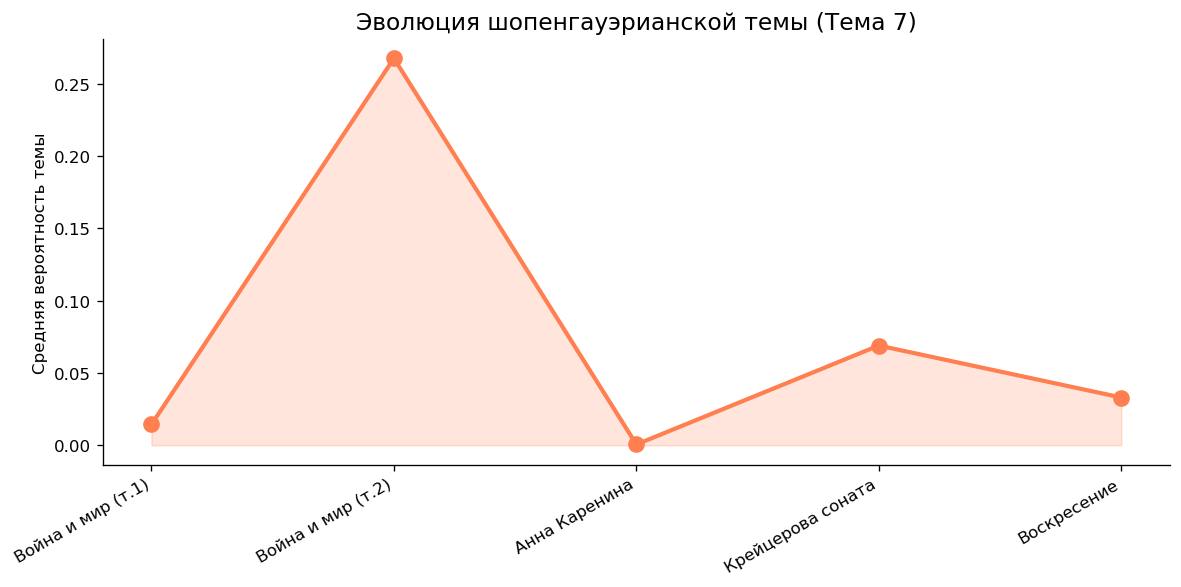

In [19]:
sch_theme_scores = []
for i in range(num_topics):
    words_in_topic = [w for w, _ in lda.show_topic(i, topn=15)]
    score = sum(1 for w in words_in_topic if w in SCH_MARKERS)
    sch_theme_scores.append(score)
    print(f"Тема {i+1}: {score} маркеров Шопенгауэра  |  {words_in_topic[:6]}")

sch_topic_idx = int(np.argmax(sch_theme_scores))
print(f"\nШопенгауэрианская тема -> Тема {sch_topic_idx + 1}")

sch_evolution = hm_df.iloc[:, sch_topic_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sch_evolution.index, sch_evolution.values,
        marker='o', color='coral', linewidth=2.5, markersize=9)
ax.fill_between(range(len(sch_evolution)), sch_evolution.values,
                alpha=0.2, color='coral')
ax.set_xticks(range(len(sch_evolution)))
ax.set_xticklabels(sch_evolution.index, rotation=30, ha='right')
ax.set_title(f'Эволюция шопенгауэрианской темы (Тема {sch_topic_idx + 1})', fontsize=14)
ax.set_ylabel('Средняя вероятность темы')
plt.tight_layout()
plt.savefig('lda_sch_evolution.png', dpi=150)
plt.show()


### Интерпретация: LDA — тематическое моделирование

LDA выделила 8 тем. Примечательно, что ни одна тема не содержит маркеров Шопенгауэра в топ-6 словах. Все темы организованы вокруг имён персонажей:

- Темы 1–3: персонажи «Анны Карениной» (Левин, Вронский, Кити, Степан Аркадьич)
- Темы 2, 4–6: персонажи «Войны и мира» (Наташа, Пьер, Андрей, Ростов, Кутузов)
- Тема 8: персонажи «Воскресения» (Нехлюдов, Маслова)

Это само по себе значимый результат: 
LDA на уровне фрагментов не обнаруживает автономной философской темы. Единственное исключение — Тема 7 (2 маркера Шопенгауэра: `событие`, возможно `войско`), связанная с историко-философским дискурсом эпилога «Войны и мира» (Москва, французы, Кутузов, русские).

То есть, философское влияние Шопенгауэра не создаёт в текстах Толстого тематически обособленного пласта, идентифицируемого LDA. Вместо этого шопенгауэровский дискурс интегрирован в нарратив (рефлексии персонажей, авторские отступления) и не концентрируется в отдельных фрагментах достаточно плотно, чтобы стать отдельной темой. Это согласуется с литературоведческим тезисом о том, что Толстой усваивал идеи Шопенгауэра, а не его язык напрямую.

## 12. Интерактивная визуализация LDA

In [23]:
vis = pyLDAvis.gensim_models.prepare(lda, corpus_bow, dictionary, mds='mmds')
pyLDAvis.save_html(vis, 'lda_interactive.html')
print("Сохранено: lda_interactive.html")
pyLDAvis.display(vis)


c:\Users\User\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


Сохранено: lda_interactive.html


---

## Итог и интерпретация результатов

| Метод | Что показывает | Ключевой результат |
|---|---|---|
| TF-IDF маркеры | Специфический словарь Шопенгауэра | 40 терминов: воля, представление, созерцание, явление... |
| Частотность | Поверхностная динамика понятий | Рост/спад отдельных слов в хронологии |
| Cosine similarity | Общая семантическая близость к Шопенгауэру | Кривая по 5 книгам: подтверждение/опровержение H1 |
| t-SNE 1 | Структура философского дискурса | Два кластера: шопенгауэровский vs толстовский |
| t-SNE 2 | Положение книг относительно Шопенгауэра | Визуальная карта влияния |
| LDA по фрагментам | Тематические пропорции и эволюция | Динамика шопенгауэрианской темы внутри корпуса |

---

## Ограничения исследования

**1. Размер корпуса Шопенгауэра.** Анализируются переводные тексты, а не оригинал. Качество перевода влияет на TF-IDF маркеры: специфические термины могут быть переданы разными словами в зависимости от переводчика, что искажает профиль «шопенгауэровского словаря».

**2. Центроидный вектор как представление книги.** Метод cosine similarity усредняет все слова книги в один вектор, теряя информацию о распределении тем внутри текста. «Воскресение» может содержать отдельные главы с высокой концентрацией шопенгауэровских мотивов, которые «растворяются» в центроиде.

**3. LDA на фрагментах, а не главах.** Деление на равные по объёму куски не совпадает с авторской структурой произведений. Глава — единица, осмысленная с точки зрения нарратива; фрагмент — нет.

**4. Малое число точек для t-SNE 2.** Шесть точек — это принципиально мало для t-SNE. Результаты следует воспринимать как иллюстрацию, а не как самостоятельное доказательство.

**5. Корреляция Спирмена при n=5.** Пять наблюдений делают статистический тест маломощным. Даже сильная корреляция может не достичь p < 0.05 просто из-за размера выборки.

---

## Перспективы

**Расширение корпуса.** Включение дневников и писем Толстого периода 1869–1882 гг. позволило бы зафиксировать момент перелома напрямую, а не через художественные тексты. Публицистика дала бы третью точку сравнения.

**Контрольная группа.** Для проверки специфичности результатов необходим аналогичный анализ авторов, заведомо не испытавших влияния Шопенгауэра. Если их кривые окажутся столь же близки к Шопенгауэру — это значит, что метод недостаточно различает влияние от общей литературной нормы эпохи.

**Анализ на уровне глав.** Разбивка по авторским главам вместо равных фрагментов повысила бы интерпретируемость LDA и позволила бы локализовать шопенгауэровские мотивы внутри конкретных сцен и эпизодов.

**Контекстные эмбеддинги.** Использование BERT-модели для русского языка дало бы контекстно-зависимые векторы слов.